<a href="https://colab.research.google.com/github/aryaanjalii203/ML-Codes/blob/main/Predicted_Stock_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-13135104.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticket_symbol, start='2015-01-01', end='2025-10-17')
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Total records downloaded: 2714
Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2025-10-10  413.489990  443.130005  411.450012  436.540009  112107900
2025-10-13  435.899994  436.890015  419.700012  423.529999   79552800
2025-10-14  429.239990  434.200012  417.859985  426.790009   72669400
2025-10-15  435.149994  440.510010  426.329987  434.899994   71558200
2025-10-16  428.750000  439.350006  421.309998  434.730011   77189900

Training the model...
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.0190
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0016
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0015
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.0013
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0011
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - lo

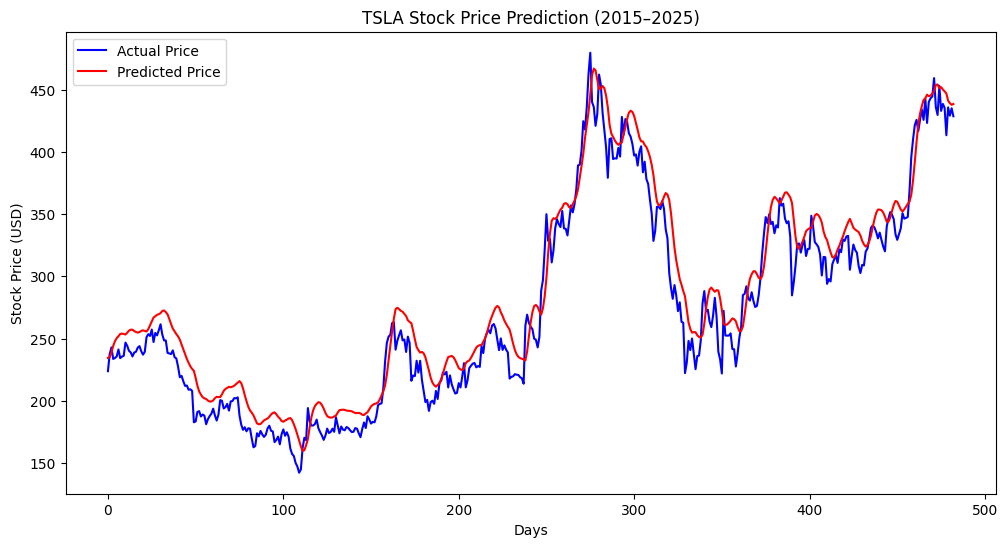

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

📅 Predicted stock price for TSLA on 2025-10-16: $438.78


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Step 1: Download 10 years of stock data
ticket_symbol = "TSLA"
stock_data = yf.download(ticket_symbol, start='2015-01-01', end='2025-10-17')

print(f"\nTotal records downloaded: {len(stock_data)}")
print(stock_data.tail())

# Step 2: Use 'Close' price
data = stock_data[['Close']].values

# Step 3: Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Step 4: Create training/testing datasets
training_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:training_size]
test_data = scaled_data[training_size:]

def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(time_step, len(dataset)):
        X.append(dataset[i-time_step:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

# Reshape inputs for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Step 5: Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Step 6: Train model
print("\nTraining the model...")
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

# Step 7: Predict test data
test_pred = model.predict(X_test)
test_pred = scaler.inverse_transform(test_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Step 8: Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Price', color='blue')
plt.plot(test_pred, label='Predicted Price', color='red')
plt.title(f'{ticket_symbol} Stock Price Prediction (2015–2025)')
plt.xlabel('Days')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()

# Step 9: Predict the price for 2025-10-16 (next day)
last_60_days = scaled_data[-60:]  # last 60 closing prices
X_future = np.array([last_60_days])
X_future = X_future.reshape((X_future.shape[0], X_future.shape[1], 1))

future_price_scaled = model.predict(X_future)
future_price = scaler.inverse_transform(future_price_scaled)

print(f"\n📅 Predicted stock price for {ticket_symbol} on 2025-10-16: ${future_price[0][0]:.2f}")